# 04 — Hasil Evaluasi

**Skripsi:** Implementasi *Time Series Foundation Model* Chronos-2 untuk Peramalan Probabilistik Harga Perak dengan Variabel Kovariat Harga Emas dan Dollar Index

Notebook ini menyusun **seluruh tabel dan gambar hasil evaluasi**: perbandingan tiga skema (Naive Persistence, Chronos-2 Zero-Shot, Chronos-2 Fine-Tuned) pada periode **uji**.

**PENTING — sumber data.** Notebook ini **hanya membaca** `results/forecasts/*_H10.parquet` (keluaran tahap 4 `run_pipeline.py`) dan `results/metrics/final_results.json` (keluaran tahap 5). Tidak ada model yang dijalankan ulang dan tidak ada prediksi baru yang dibentuk pada data uji — seluruh analisis di sini murni pengolahan ulang angka yang sudah tersimpan di disk. Ini yang memungkinkan figure diperbaiki berkali-kali tanpa biaya komputasi maupun risiko menyentuh data uji lebih dari sekali.

**Ruang lingkup dan batasannya:**

- Seluruh metrik (`src.evaluation`) dan seluruh gambar baku (`src.visualization`) diimpor apa adanya. Tidak ada fungsi metrik, agregasi, atau pembentukan gambar yang ditulis ulang di sini; yang ditulis langsung di cell hanyalah kode presentasi (pemilihan jendela, narasi otomatis, satu gambar diagnostik yang memang khusus untuk notebook ini).
- Data uji tidak "disentuh" dalam arti diramalkan ulang. Yang dibaca adalah *hasil* ramalan yang sudah tersimpan.
- Tabel perbandingan utama (bagian 3) diambil **apa adanya** dari `results/metrics/comparison_table.md`, bukan dihitung ulang, sehingga angkanya dijamin sama persis dengan yang dilaporkan `run_pipeline.py`.
- Impor `src.forecasting` menarik `autogluon.timeseries` sebagai dependensi modul (dipakai untuk tipe `TimeSeriesDataFrame` di tempat lain pada modul itu) — ini murni biaya *import* library, **bukan** eksekusi model.

In [1]:
import json
import sys
from pathlib import Path

# Tambahkan akar project ke sys.path agar `import src.*` bekerja dari folder notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display
from scipy.stats import pearsonr

# Seluruh metrik dan gambar baku diimpor dari src/ -- tidak ada yang
# ditulis ulang di notebook ini.
from src.evaluation import aggregate_metrics, crps_elementwise
from src.forecasting import ALL_SCHEMES, load_forecast_arrays
from src.preprocessing import get_target_column
from src.utils import load_config, resolve_path
from src.visualization import (
    plot_coverage_calibration,
    plot_error_distribution,
    plot_forecast_example,
    plot_metrics_by_horizon,
)

%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

CONFIG = load_config()
HORIZON = CONFIG["model"]["prediction_length"]
QUANTILE_LEVELS = CONFIG["model"]["quantile_levels"]
FIGURE_DPI = CONFIG["visualization"]["figure_dpi"]
TARGET_COL = get_target_column(CONFIG)

METRICS_DIR = resolve_path(CONFIG["paths"]["metrics_dir"])
FIGURES_DIR = resolve_path(CONFIG["paths"]["figures_dir"])
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Label dan palet warna dipakai konsisten dengan src/visualization.py
SCHEME_LABELS = {
    "naive": "Naive Persistence",
    "zeroshot": "Chronos-2 Zero-Shot",
    "finetuned": "Chronos-2 Fine-Tuned",
}
SCHEME_COLORS = {"naive": "#898781", "zeroshot": "#2a78d6", "finetuned": "#eb6834"}
SCHEME_ORDER = ("naive", "zeroshot", "finetuned")

print("Horizon H         :", HORIZON)
print("Jumlah kuantil    :", len(QUANTILE_LEVELS))
print("Direktori metrics :", METRICS_DIR)
print("Direktori figures :", FIGURES_DIR)

Horizon H         : 10
Jumlah kuantil    : 13
Direktori metrics : D:\project-skripsi\results\metrics
Direktori figures : D:\project-skripsi\results\figures


## 1. Memuat prediksi ketiga skema dan hasil akhir

`load_forecast_arrays` (dari `src.forecasting`) membaca kembali `results/forecasts/{skema}_H{H}.parquet` pada `split="test"` dan menyusunnya menjadi array `(n_windows, H)` / `(n_windows, H, n_quantiles)`. `final_results.json` adalah ringkasan lengkap yang sudah disusun tahap 5 `run_pipeline.py` (metrik, protokol, uji Diebold-Mariano).

In [2]:
forecasts = {
    scheme: load_forecast_arrays(scheme, horizon=HORIZON, split="test", config=CONFIG)
    for scheme in ALL_SCHEMES
}

with (METRICS_DIR / "final_results.json").open("r", encoding="utf-8") as file:
    final_results = json.load(file)

print(f"{'Skema':<24}{'Jendela':>10}   Origin pertama -> Origin terakhir")
for scheme in SCHEME_ORDER:
    forecast = forecasts[scheme]
    first_date = pd.Timestamp(forecast["origin_dates"][0]).date()
    last_date = pd.Timestamp(forecast["origin_dates"][-1]).date()
    print(f"{SCHEME_LABELS[scheme]:<24}{forecast['y_true'].shape[0]:>10}   {first_date} -> {last_date}")

print()
print("Protokol evaluasi (final_results.json):")
for key, value in final_results["protocol"].items():
    print(f"  {key:<24}: {value}")

Skema                      Jendela   Origin pertama -> Origin terakhir
Naive Persistence              181   2025-11-11 -> 2026-08-03
Chronos-2 Zero-Shot            181   2025-11-11 -> 2026-08-03
Chronos-2 Fine-Tuned           181   2025-11-11 -> 2026-08-03

Protokol evaluasi (final_results.json):
  horizon                 : 10
  stride                  : 1
  max_context             : 1024
  n_windows               : 181
  test_start              : 2025-11-11
  test_end                : 2026-08-03
  quantile_levels         : [0.025, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.975]
  known_covariates_names  : []
  context_type            : expanding (seluruh riwayat sampai origin, dibatasi max_context)
  schemes_evaluated       : ['zeroshot', 'finetuned', 'naive']


## 2. Bukti kesamaan jendela origin antar skema

Perbandingan MAE/CRPS/DM antar skema hanya sah bila ketiganya dievaluasi pada **himpunan jendela rolling-origin yang persis sama**. `run_pipeline.py` sudah menjamin ini lewat `build_origins()` yang dipanggil sekali untuk seluruh skema, tetapi notebook ini membuktikannya ulang secara eksplisit dari berkas yang tersimpan — bila baris `assert` di bawah gagal, seluruh tabel dan uji signifikansi pada notebook ini tidak sah dan tidak boleh dilaporkan.

In [3]:
origin_index_sets = {scheme: forecasts[scheme]["origins"] for scheme in SCHEME_ORDER}
origin_date_sets = {
    scheme: [pd.Timestamp(d) for d in forecasts[scheme]["origin_dates"]] for scheme in SCHEME_ORDER
}
reference_scheme = SCHEME_ORDER[0]

print(f"{'Skema':<24}{'n origin':>10}   Identik dgn referensi ('{SCHEME_LABELS[reference_scheme]}')")
for scheme in SCHEME_ORDER:
    same_index = origin_index_sets[scheme] == origin_index_sets[reference_scheme]
    same_date = origin_date_sets[scheme] == origin_date_sets[reference_scheme]
    print(f"{SCHEME_LABELS[scheme]:<24}{len(origin_index_sets[scheme]):>10}   {same_index and same_date}")

assert origin_index_sets["naive"] == origin_index_sets["zeroshot"] == origin_index_sets["finetuned"], (
    "Daftar posisi origin antar skema TIDAK identik -- protokol rolling origin dilanggar. "
    "Perbandingan pada notebook ini tidak sah bila baris ini gagal."
)
assert origin_date_sets["naive"] == origin_date_sets["zeroshot"] == origin_date_sets["finetuned"], (
    "Daftar tanggal origin antar skema TIDAK identik -- protokol rolling origin dilanggar."
)

n_windows = len(origin_index_sets[reference_scheme])
print()
print(
    f"LULUS: ketiga skema memakai {n_windows} jendela rolling-origin yang PERSIS SAMA "
    f"({origin_date_sets[reference_scheme][0].date()} s.d. {origin_date_sets[reference_scheme][-1].date()}). "
    "Perbandingan pada notebook ini karenanya adil."
)

Skema                     n origin   Identik dgn referensi ('Naive Persistence')
Naive Persistence              181   True
Chronos-2 Zero-Shot            181   True
Chronos-2 Fine-Tuned           181   True

LULUS: ketiga skema memakai 181 jendela rolling-origin yang PERSIS SAMA (2025-11-11 s.d. 2026-08-03). Perbandingan pada notebook ini karenanya adil.


## 3. Tabel perbandingan utama

Ditampilkan **apa adanya** dari `results/metrics/comparison_table.md` — bukan dihitung ulang di notebook ini, sehingga dijamin sama persis dengan yang disusun `run_pipeline.py` tahap 5.

In [4]:
comparison_table_path = METRICS_DIR / "comparison_table.md"
comparison_table_text = comparison_table_path.read_text(encoding="utf-8")
display(Markdown(comparison_table_text))

# Tabel Perbandingan Skema

Protokol: rolling origin (expanding window), H = 10 hari perdagangan, stride = 1, 181 jendela pada periode uji (2025-11-11 s.d. 2026-08-03).

Seluruh skema dievaluasi pada **himpunan jendela rolling origin yang persis sama**. Kovariat Emas dan Dollar Index diperlakukan sebagai *past-only*: nilai masa depannya tidak pernah diberikan ke model.

## Tabel 1 — Perbandingan akurasi dan kalibrasi

| Skema | MAE | RMSE | MAPE (%) | MASE | CRPS | nCRPS | Cov80 | Cov95 | Width80 | CrossRate |
|---|---|---|---|---|---|---|---|---|---|---|
| Naive Persistence | 5.6810 | 8.2954 | 7.511 | 1.0000 | 3.6997 | 0.051063 | 0.7680 | 0.9149 | 19.6722 | 0.000000 |
| Chronos-2 Zero-Shot | 6.0303 | 9.1035 | 7.977 | 1.0615 | 3.8774 | 0.053516 | 0.6801 | 0.9094 | 14.8809 | 0.000000 |
| Chronos-2 Fine-Tuned | 6.0581 | 8.9864 | 8.012 | 1.0664 | 3.9578 | 0.054626 | 0.6630 | 0.8751 | 14.8096 | 0.000000 |

Keterangan kolom: MASE = MAE skema / MAE baseline pada jendela yang sama (< 1 berarti mengungguli baseline). nCRPS = CRPS / rata-rata |y|. Cov80 dan Cov95 = cakupan empiris interval 80% dan 95% (target 0,80 dan 0,95). Width80 = lebar rata-rata interval 80% dalam USD — wajib dibaca bersama Cov80, karena cakupan tinggi yang dicapai lewat interval kelewat lebar bukan kalibrasi yang baik. CrossRate = proporsi pelanggaran urutan kuantil.

## Tabel 2 — Uji Diebold-Mariano (rugi = galat absolut, HAC Newey-West)

| Perbandingan | Selisih rugi rata-rata | Statistik DM | p-value | Lag HAC | Signifikan (α = 0.05) | Lebih baik |
|---|---|---|---|---|---|---|
| Chronos-2 Zero-Shot vs Chronos-2 Fine-Tuned **(uji utama)** | -0.027842 | -0.2018 | 0.8401 | 9 | tidak | tidak terbukti berbeda |
| Chronos-2 Zero-Shot vs Naive Persistence | 0.349285 | 1.2688 | 0.2045 | 9 | tidak | tidak terbukti berbeda |
| Chronos-2 Fine-Tuned vs Naive Persistence | 0.377127 | 1.8109 | 0.0702 | 9 | tidak | tidak terbukti berbeda |

H0 uji DM: kedua ramalan sama akuratnya. Statistik negatif berarti skema pertama memiliki rugi lebih kecil. Karena jendela rolling origin saling tumpang tindih, ragam diestimasi dengan HAC Newey-West berlag H − 1 = 9. **p-value di atas α berarti perbedaan angka pada Tabel 1 tidak terbukti secara statistik dan tidak boleh dinarasikan sebagai keunggulan.**


## 4. Metrik terhadap horizon: MAE dan CRPS untuk h = 1..10

`aggregate_metrics` (dari `src.evaluation`) dipanggil pada ketiga skema dengan `y_naive` yang sama, lalu `plot_metrics_by_horizon` (dari `src.visualization`) menggambar MAE (akurasi titik) dan CRPS (kualitas sebaran) terhadap horizon dalam satu gambar. Kurva yang mendatar atau bahkan menurun terhadap h patut dicurigai — ramalan harga aset umumnya memburuk kira-kira sebanding akar horizon.

Tersimpan: D:\project-skripsi\results\figures\eval_metrik_per_horizon.png


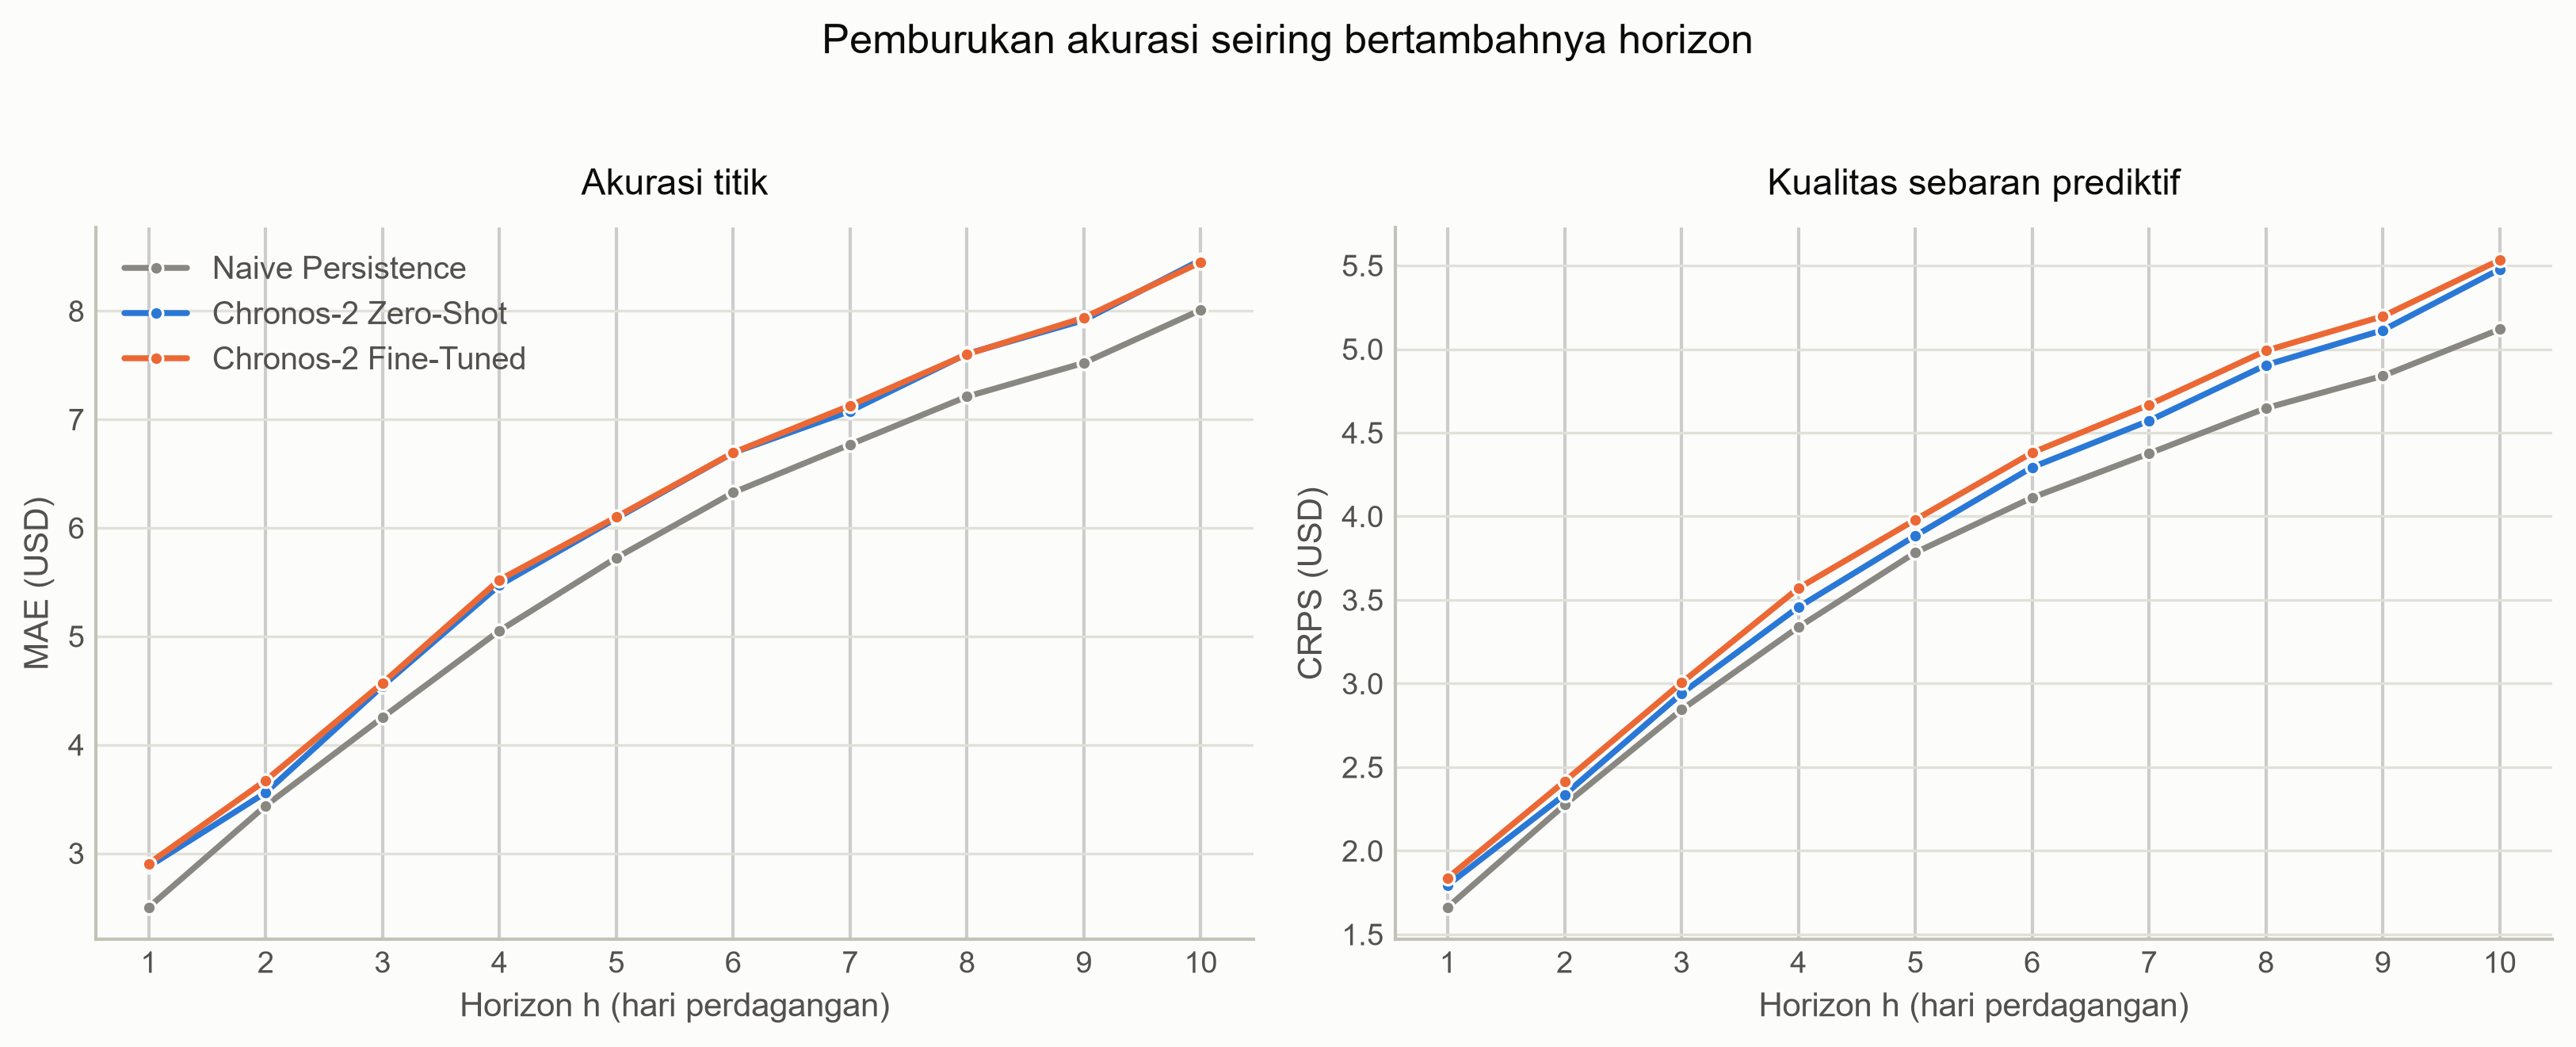

In [5]:
naive_point = forecasts["naive"]["y_pred"]
metrics = {
    scheme: aggregate_metrics(
        forecasts[scheme]["y_true"],
        forecasts[scheme]["y_pred_quantiles"],
        QUANTILE_LEVELS,
        y_naive=naive_point,
        config=CONFIG,
    )
    for scheme in SCHEME_ORDER
}

metrics_horizon_path = FIGURES_DIR / "eval_metrik_per_horizon.png"
plot_metrics_by_horizon(metrics, metrics_horizon_path, FIGURE_DPI, config=CONFIG)
print("Tersimpan:", metrics_horizon_path)
Image(filename=str(metrics_horizon_path))

**Yang perlu diperhatikan pada gambar di atas:** apakah jarak antar kurva (Naive vs Chronos-2) melebar atau menyempit seiring bertambahnya h, dan apakah urutan ranking skema stabil di seluruh horizon atau berbalik di suatu titik. Kesimpulan kuantitatif atas pola ini disusun pada bagian 9.

## 5. Reliability diagram — kalibrasi interval prediksi

Panel kiri membandingkan cakupan nominal terhadap cakupan empiris (`plot_coverage_calibration`, `src.visualization`): titik di **bawah** garis diagonal berarti interval terlalu sempit (model terlalu percaya diri), di **atas** berarti terlalu lebar (terlalu berhati-hati). Panel kanan menampilkan lebar interval rata-rata pada tiap tingkat — wajib dibaca berdampingan, karena cakupan tinggi yang dicapai dengan interval yang jauh lebih lebar bukan kalibrasi yang baik.

Tersimpan: D:\project-skripsi\results\figures\eval_reliability_diagram.png


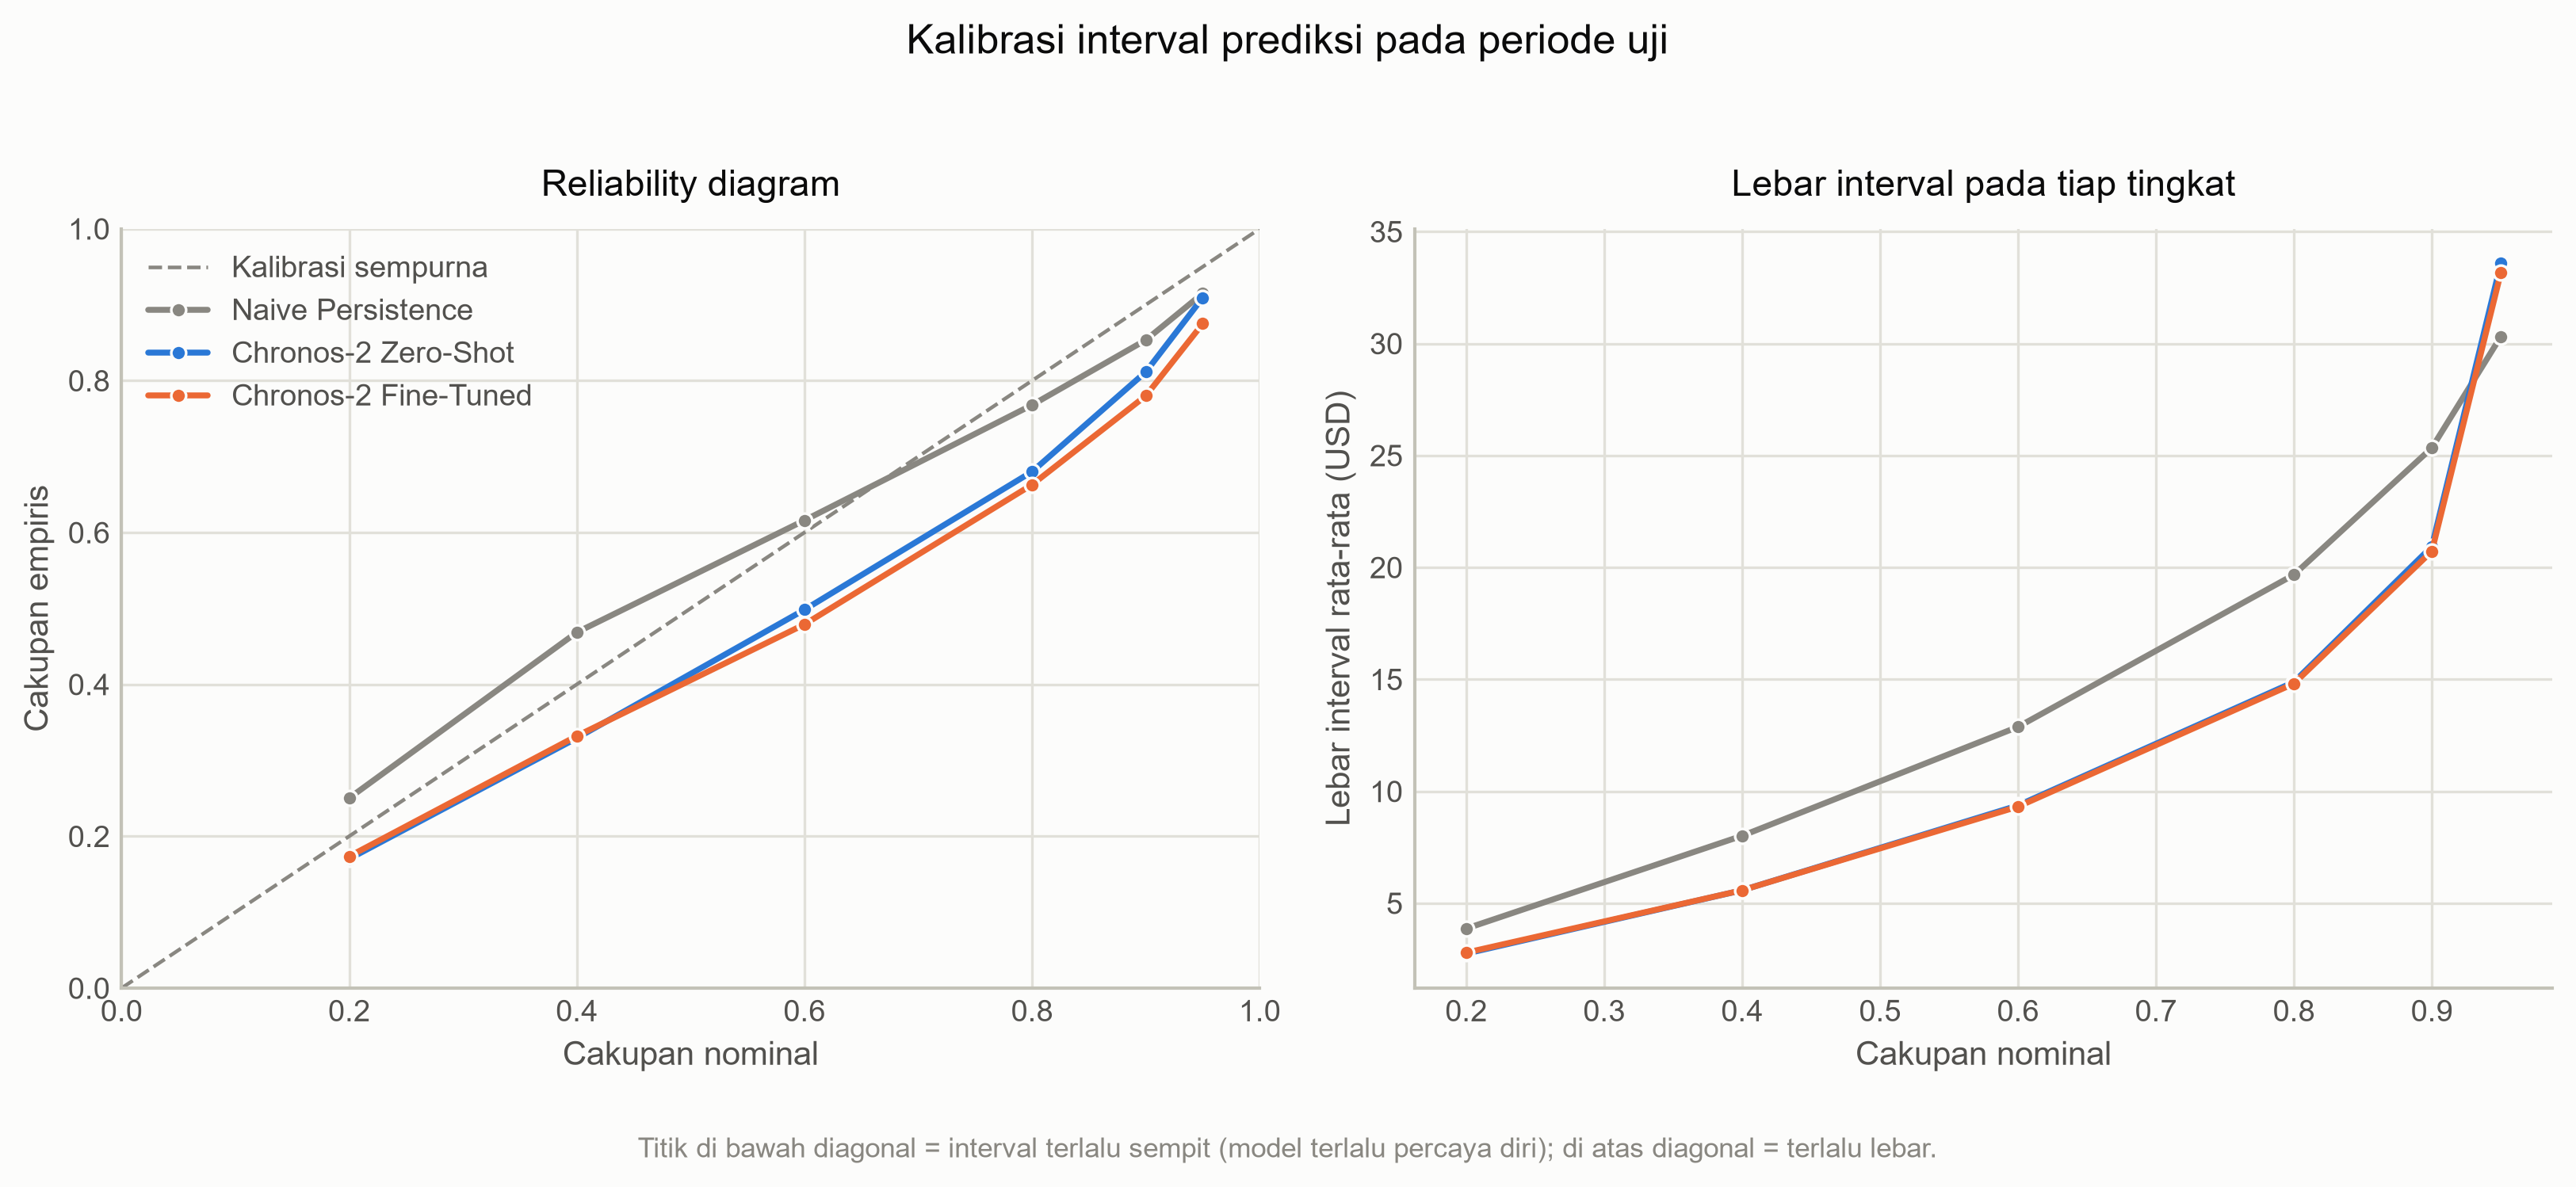

In [6]:
reliability_path = FIGURES_DIR / "eval_reliability_diagram.png"
plot_coverage_calibration(forecasts, reliability_path, FIGURE_DPI, config=CONFIG)
print("Tersimpan:", reliability_path)
Image(filename=str(reliability_path))

In [7]:
print(f"{'Skema':<24}{'Cov80':>10}{'Target':>10}{'Selisih':>10}   Interpretasi")
for scheme in SCHEME_ORDER:
    cov80 = metrics[scheme]["overall"]["coverage"]["0.8"]
    diff = cov80 - 0.80
    if diff < -0.02:
        verdict = "terlalu sempit (model terlalu percaya diri)"
    elif diff > 0.02:
        verdict = "terlalu lebar (model terlalu berhati-hati)"
    else:
        verdict = "mendekati target"
    print(f"{SCHEME_LABELS[scheme]:<24}{cov80:>10.4f}{0.80:>10.2f}{diff:>+10.4f}   {verdict}")

Skema                        Cov80    Target   Selisih   Interpretasi
Naive Persistence           0.7680      0.80   -0.0320   terlalu sempit (model terlalu percaya diri)
Chronos-2 Zero-Shot         0.6801      0.80   -0.1199   terlalu sempit (model terlalu percaya diri)
Chronos-2 Fine-Tuned        0.6630      0.80   -0.1370   terlalu sempit (model terlalu percaya diri)


## 6. Sebaran galat absolut per skema dan uji Diebold-Mariano

Boxplot (`plot_error_distribution`, `src.visualization`) memperlihatkan seluruh sebaran galat absolut — median, rentang antar-kuartil, dan ekor — bukan hanya rata-ratanya (MAE). Panel kanannya memecah sebaran menurut horizon untuk skema dengan MAE terkecil.

Uji Diebold-Mariano dimuat langsung dari `final_results.json` (sudah dihitung `run_pipeline.py` lewat `src.evaluation.diebold_mariano`, rugi = galat absolut, koreksi HAC Newey-West berlag H − 1) — **tidak dihitung ulang** di sini, satu sumber kebenaran untuk angka yang sama.

Tersimpan: D:\project-skripsi\results\figures\eval_boxplot_galat.png


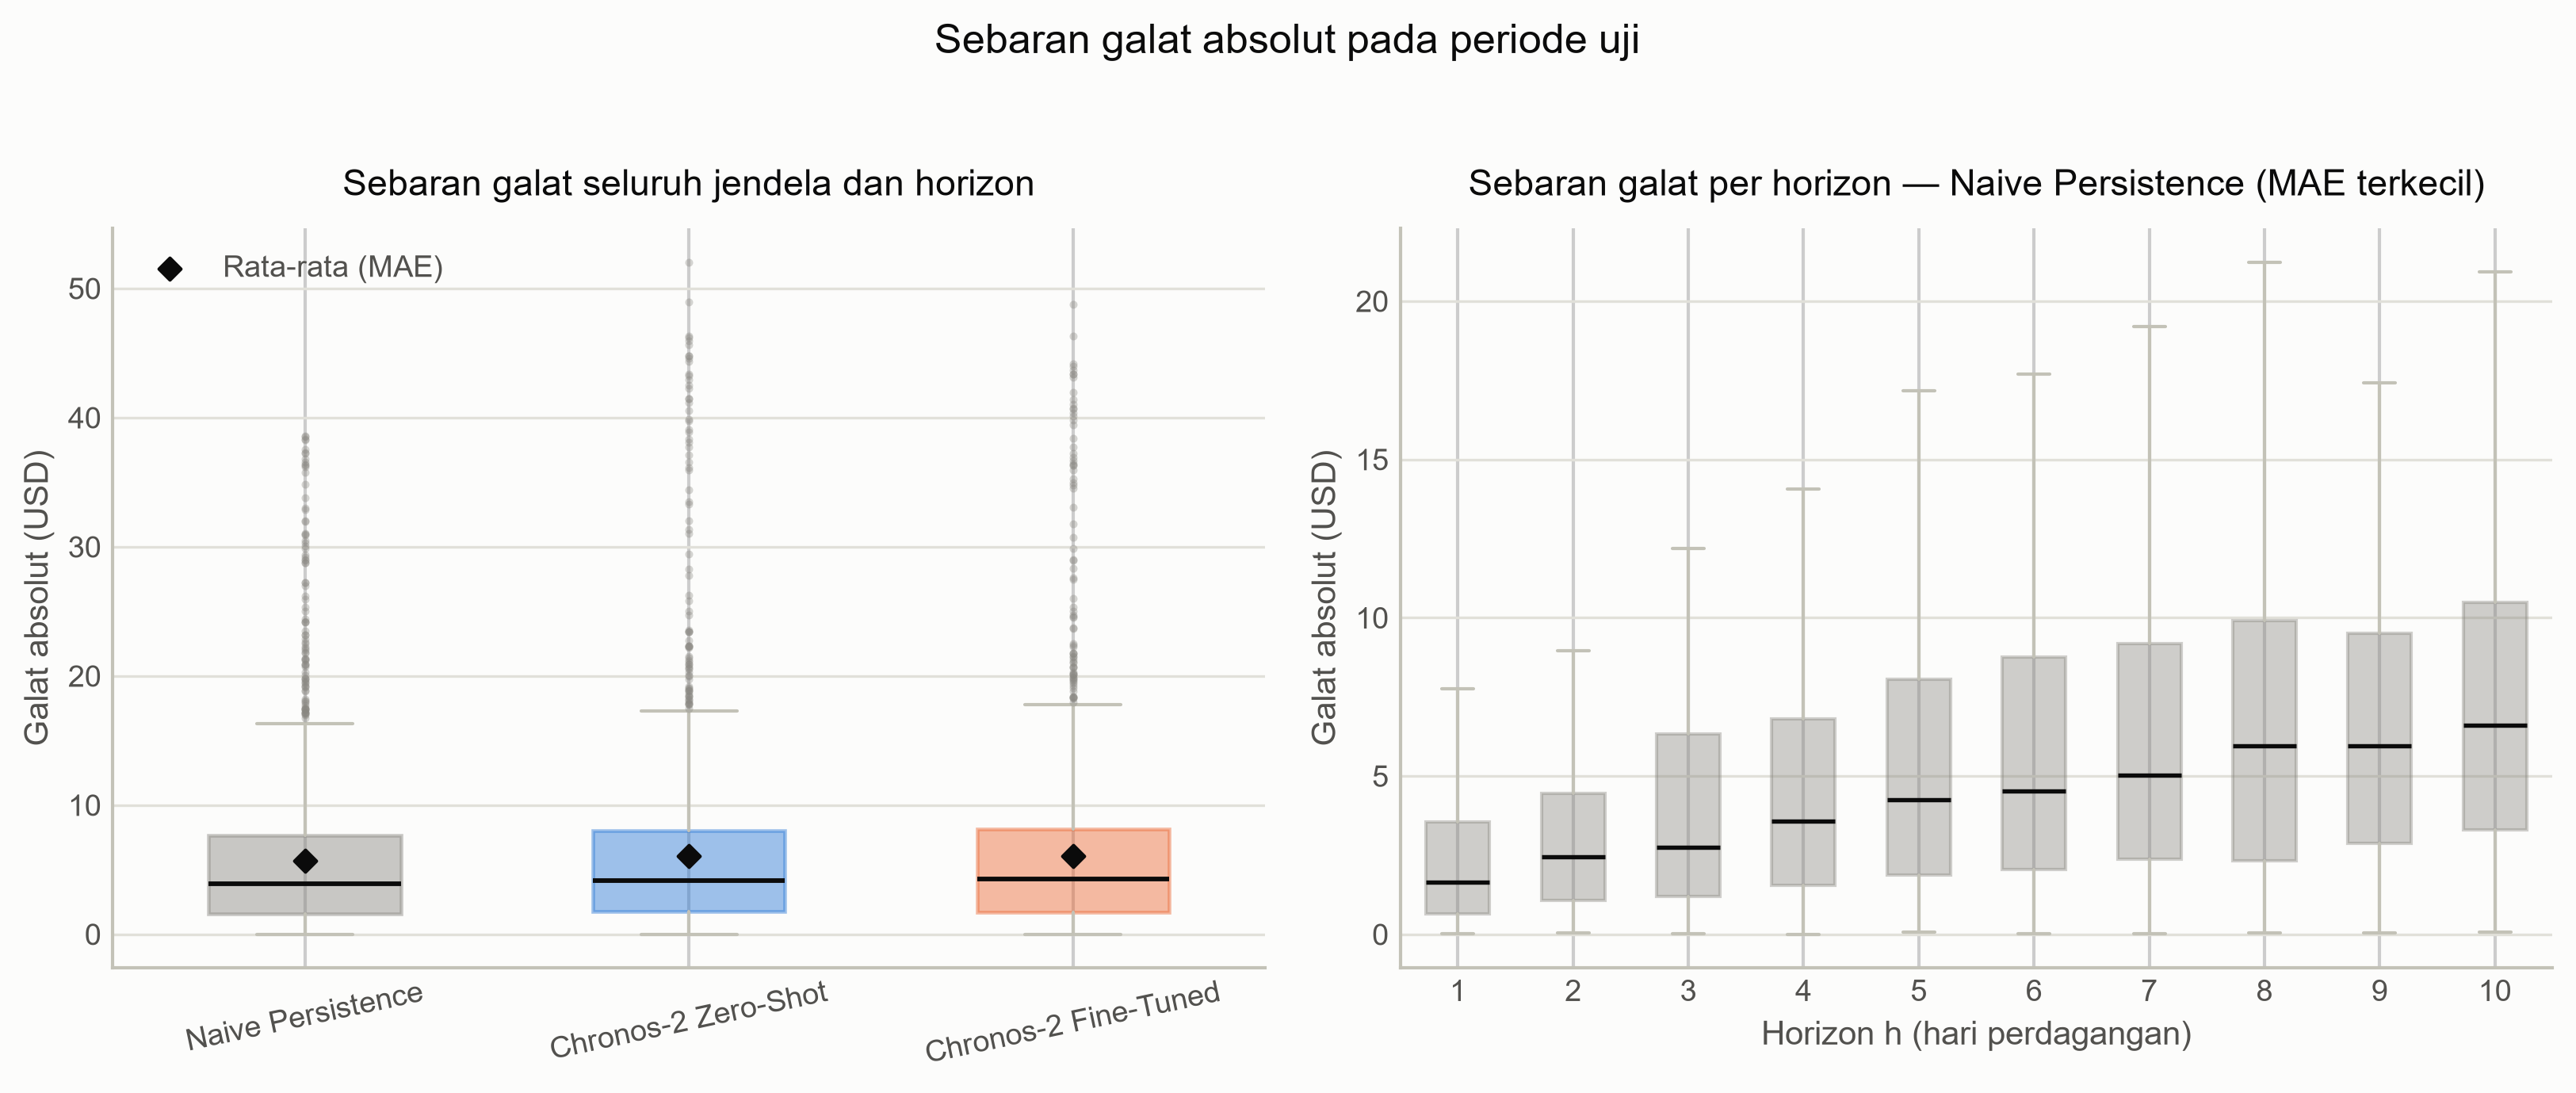

In [8]:
boxplot_path = FIGURES_DIR / "eval_boxplot_galat.png"
plot_error_distribution(forecasts, boxplot_path, FIGURE_DPI, config=CONFIG)
print("Tersimpan:", boxplot_path)
Image(filename=str(boxplot_path))

In [9]:
dm_tests = final_results["diebold_mariano"]
alpha = CONFIG["evaluation"]["diebold_mariano"]["alpha"]

dm_table = pd.DataFrame(dm_tests)[
    ["label", "primary", "mean_loss_differential", "statistic", "p_value", "hac_lag", "significant"]
].set_index("label")
display(dm_table)

,primary,mean_loss_differential,statistic,p_value,hac_lag,significant
label,,,,,,
Chronos-2 Zero-Shot vs Chronos-2 Fine-Tuned,True,-0.0278,-0.2018,0.8401,9,False
Chronos-2 Zero-Shot vs Naive Persistence,False,0.3493,1.2688,0.2045,9,False
Chronos-2 Fine-Tuned vs Naive Persistence,False,0.3771,1.8109,0.0702,9,False


In [10]:
print(f"Interpretasi (alfa = {alpha:g}):")
for test in dm_tests:
    marker = " [UJI UTAMA]" if test["primary"] else ""
    if test["significant"]:
        kesimpulan = (
            f"perbedaan SIGNIFIKAN (p = {test['p_value']:.4f} < {alpha:g}); "
            f"{SCHEME_LABELS.get(test['better_scheme'], test['better_scheme'])} terbukti lebih akurat."
        )
    else:
        kesimpulan = (
            f"perbedaan TIDAK signifikan (p = {test['p_value']:.4f} >= {alpha:g}); H0 (kedua ramalan "
            "sama akuratnya) tidak dapat ditolak, sehingga selisih MAE pada tabel bagian 3 TIDAK boleh "
            "dinarasikan sebagai keunggulan salah satu skema."
        )
    print(f"- {test['label']}{marker}: {kesimpulan}")

Interpretasi (alfa = 0.05):
- Chronos-2 Zero-Shot vs Chronos-2 Fine-Tuned [UJI UTAMA]: perbedaan TIDAK signifikan (p = 0.8401 >= 0.05); H0 (kedua ramalan sama akuratnya) tidak dapat ditolak, sehingga selisih MAE pada tabel bagian 3 TIDAK boleh dinarasikan sebagai keunggulan salah satu skema.
- Chronos-2 Zero-Shot vs Naive Persistence: perbedaan TIDAK signifikan (p = 0.2045 >= 0.05); H0 (kedua ramalan sama akuratnya) tidak dapat ditolak, sehingga selisih MAE pada tabel bagian 3 TIDAK boleh dinarasikan sebagai keunggulan salah satu skema.
- Chronos-2 Fine-Tuned vs Naive Persistence: perbedaan TIDAK signifikan (p = 0.0702 >= 0.05); H0 (kedua ramalan sama akuratnya) tidak dapat ditolak, sehingga selisih MAE pada tabel bagian 3 TIDAK boleh dinarasikan sebagai keunggulan salah satu skema.


## 7. Tiga contoh jendela ramalan: terbaik, median, terburuk

Jendela dipilih **otomatis berdasarkan CRPS per jendela** milik skema Chronos-2 **Fine-Tuned** (skema utama yang diteliti) — bukan dipilih dengan melihat gambarnya lebih dulu, dan bukan pula jendela "merata sepanjang periode" seperti pada `results/figures/02_contoh_ramalan.png` bawaan pipeline. Ketiga skema digambar berdampingan pada jendela yang **sama persis**, sehingga perbedaan lebar pita dan akurasi median dapat dibandingkan langsung secara visual.

In [11]:
selection_scheme = "finetuned"
selection_forecast = forecasts[selection_scheme]

per_window_crps = crps_elementwise(
    selection_forecast["y_true"], selection_forecast["y_pred_quantiles"], QUANTILE_LEVELS
).mean(axis=1)

order = np.argsort(per_window_crps)
idx_best = int(order[0])
idx_worst = int(order[-1])
idx_median = int(order[len(order) // 2])
selected_windows = {"terbaik": idx_best, "median": idx_median, "terburuk": idx_worst}

print(f"Jendela dipilih berdasarkan CRPS skema '{SCHEME_LABELS[selection_scheme]}':")
for label, idx in selected_windows.items():
    origin_date = pd.Timestamp(selection_forecast["origin_dates"][idx]).date()
    print(f"  {label:<10} jendela #{idx:<4} origin {origin_date}   CRPS = {per_window_crps[idx]:.4f}")

Jendela dipilih berdasarkan CRPS skema 'Chronos-2 Fine-Tuned':
  terbaik    jendela #1    origin 2025-11-12   CRPS = 0.8050
  median     jendela #7    origin 2025-11-20   CRPS = 2.9730
  terburuk   jendela #54   origin 2026-01-30   CRPS = 31.2222


Tersimpan: D:\project-skripsi\results\figures\eval_contoh_jendela_terpilih.png
Urutan baris (atas -> bawah): terbaik, median, terburuk


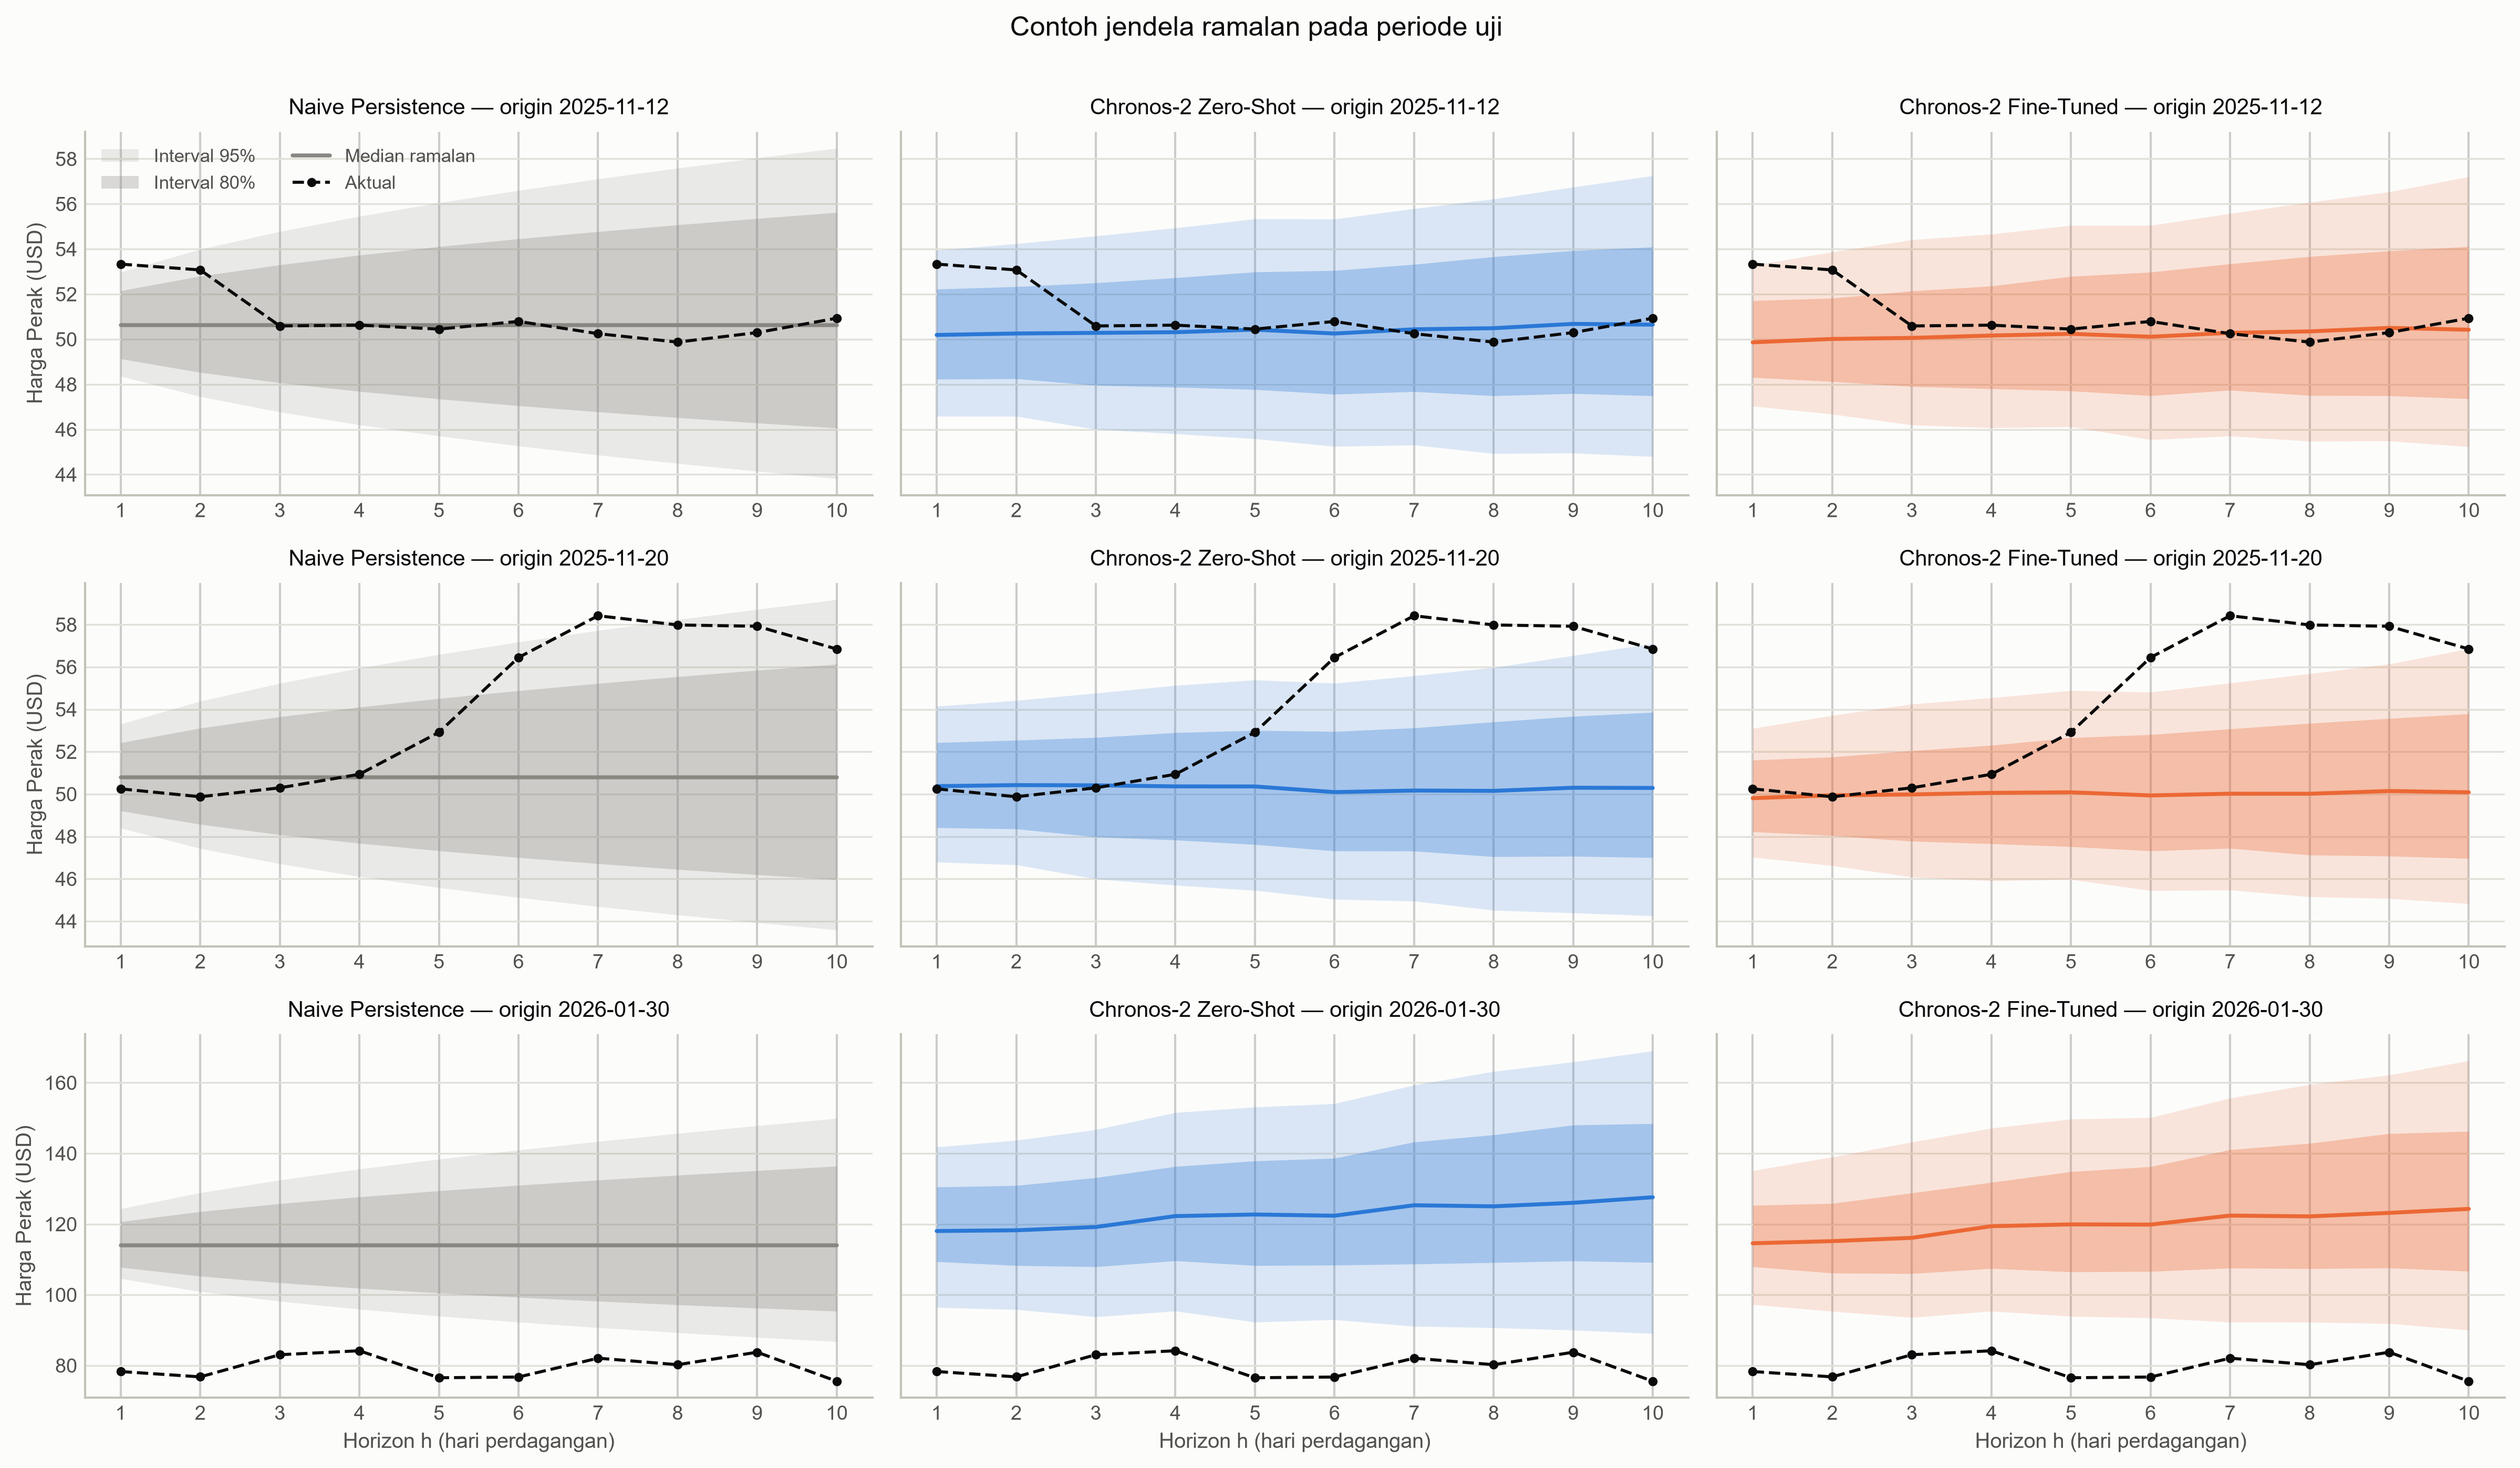

In [12]:
example_windows_path = FIGURES_DIR / "eval_contoh_jendela_terpilih.png"
plot_forecast_example(
    forecasts,
    example_windows_path,
    FIGURE_DPI,
    config=CONFIG,
    schemes=SCHEME_ORDER,
    window_indices=[idx_best, idx_median, idx_worst],
)
print("Tersimpan:", example_windows_path)
print("Urutan baris (atas -> bawah): terbaik, median, terburuk")
Image(filename=str(example_windows_path))

CRPS jendela yang sama pada ketiga skema, untuk konfirmasi bahwa jendela "sulit" bagi satu skema umumnya juga sulit bagi skema lain (karena sumber kesulitannya adalah pergerakan pasar pada periode itu, bukan model tertentu):

In [13]:
comparison_rows = []
for label, idx in selected_windows.items():
    row = {
        "jendela": label,
        "origin_date": pd.Timestamp(selection_forecast["origin_dates"][idx]).date(),
    }
    for scheme in SCHEME_ORDER:
        window_crps = crps_elementwise(
            forecasts[scheme]["y_true"][idx : idx + 1],
            forecasts[scheme]["y_pred_quantiles"][idx : idx + 1],
            QUANTILE_LEVELS,
        ).mean()
        row[f"crps_{scheme}"] = window_crps
    comparison_rows.append(row)

pd.DataFrame(comparison_rows).set_index("jendela")

,origin_date,crps_naive,crps_zeroshot,crps_finetuned
jendela,,,,
terbaik,2025-11-12,0.8217,0.7406,0.8050
median,2025-11-20,2.2555,2.8925,2.9730
terburuk,2026-01-30,26.2167,33.0741,31.2222


## 8. Kapan model gagal? Galat vs volatilitas pasar

Pertanyaannya: apakah galat memuncak justru pada periode volatilitas tinggi? Volatilitas dihitung dengan **definisi yang identik dengan notebook 01** (simpangan baku bergulir log-return 30 hari, disetahunkan dengan faktor $\sqrt{252}$), dievaluasi pada seluruh deret `aligned.csv` agar 30 hari pertama periode uji tetap punya konteks dari periode validasi. Gambar ini bersifat diagnostik khusus notebook ini sehingga tidak ada padanannya di `src.visualization` (lima gambar baku modul itu tidak memotret hubungan galat-vs-waktu).

In [14]:
VOLATILITY_WINDOW = 30       # sama seperti notebook 01
TRADING_DAYS_PER_YEAR = 252  # sama seperti notebook 01

aligned_path = resolve_path(CONFIG["data"]["processed_dir"]) / "aligned.csv"
aligned = pd.read_csv(aligned_path, index_col="date", parse_dates=["date"]).sort_index()

silver_log_returns = np.log(aligned[TARGET_COL] / aligned[TARGET_COL].shift(1))
rolling_volatility = (
    silver_log_returns.rolling(VOLATILITY_WINDOW).std() * np.sqrt(TRADING_DAYS_PER_YEAR)
)

per_window_mae = {
    scheme: np.abs(forecasts[scheme]["y_true"] - forecasts[scheme]["y_pred"]).mean(axis=1)
    for scheme in SCHEME_ORDER
}
origin_dates = pd.DatetimeIndex(origin_date_sets[reference_scheme])

error_over_time = pd.DataFrame(per_window_mae, index=origin_dates)
error_over_time["volatilitas_tahunan_%"] = rolling_volatility.reindex(origin_dates).to_numpy() * 100

assert error_over_time["volatilitas_tahunan_%"].notna().all(), (
    "Ada tanggal origin yang volatilitasnya tidak dapat dihitung -- periksa kelengkapan aligned.csv."
)
error_over_time.head()

,naive,zeroshot,finetuned,volatilitas_tahunan_%
2025-11-11,0.8732,1.4554,1.5265,47.4949
2025-11-12,0.7300,0.8626,0.9640,49.3130
2025-11-13,2.3526,2.3234,1.8655,48.4763
2025-11-14,2.4318,2.3386,2.0152,49.9689
2025-11-17,1.8084,2.0643,2.1712,49.9107


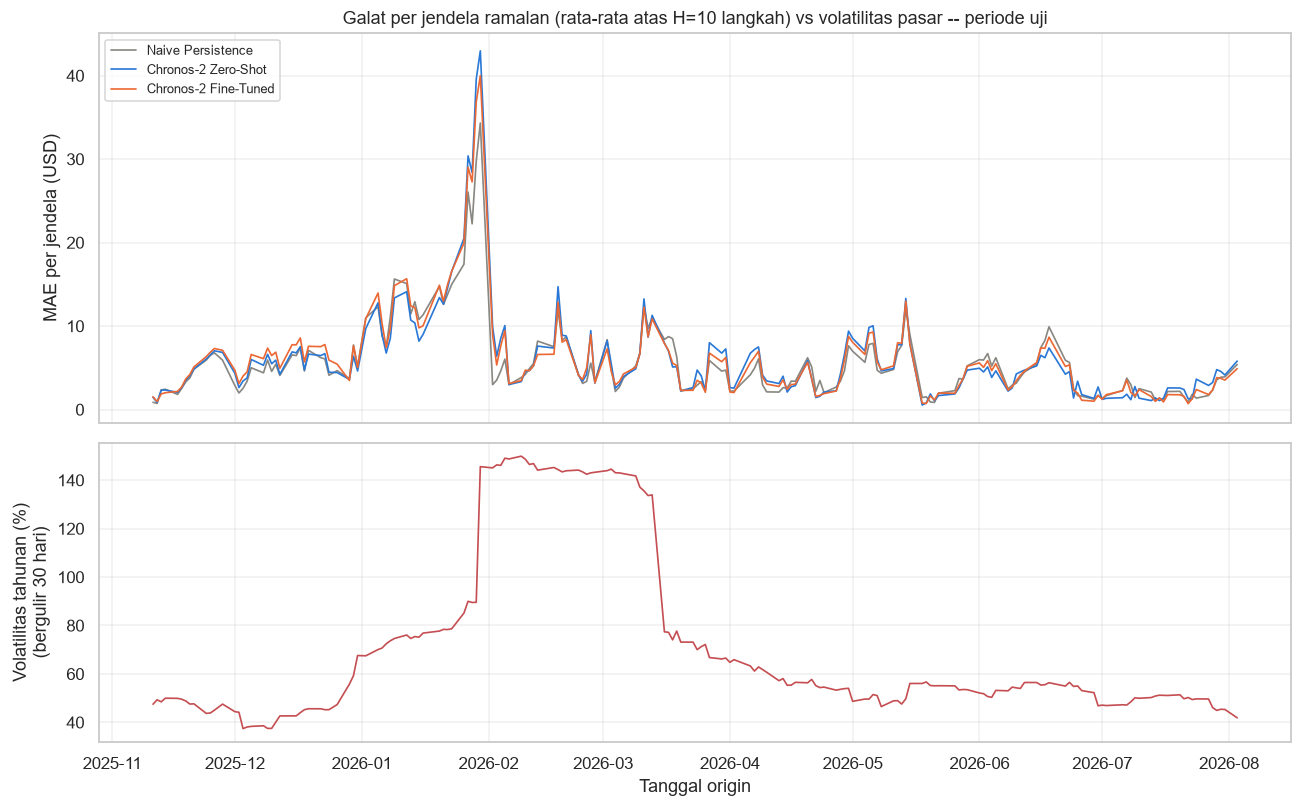

Tersimpan: D:\project-skripsi\results\figures\eval_galat_vs_volatilitas.png


In [15]:
fig, axes = plt.subplots(
    2, 1, figsize=(12, 7.5), sharex=True, gridspec_kw={"height_ratios": [1.3, 1]}
)

for scheme in SCHEME_ORDER:
    axes[0].plot(
        error_over_time.index,
        error_over_time[scheme],
        color=SCHEME_COLORS[scheme],
        linewidth=1.1,
        label=SCHEME_LABELS[scheme],
    )
axes[0].set_ylabel("MAE per jendela (USD)")
axes[0].set_title(
    f"Galat per jendela ramalan (rata-rata atas H={HORIZON} langkah) vs volatilitas pasar -- periode uji"
)
axes[0].legend(loc="upper left", fontsize=8.5)
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    error_over_time.index,
    error_over_time["volatilitas_tahunan_%"],
    color="#c44e52",
    linewidth=1.1,
)
axes[1].set_ylabel("Volatilitas tahunan (%)\n(bergulir 30 hari)")
axes[1].set_xlabel("Tanggal origin")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
error_volatility_path = FIGURES_DIR / "eval_galat_vs_volatilitas.png"
fig.savefig(error_volatility_path, dpi=FIGURE_DPI)
plt.show()

print("Tersimpan:", error_volatility_path)

In [16]:
correlation_rows = []
for scheme in SCHEME_ORDER:
    r, p_value = pearsonr(error_over_time[scheme], error_over_time["volatilitas_tahunan_%"])
    correlation_rows.append({"skema": SCHEME_LABELS[scheme], "korelasi_pearson_r": r, "p_value": p_value})

correlation_table = pd.DataFrame(correlation_rows).set_index("skema")
display(correlation_table)

print()
for row in correlation_rows:
    signifikan = "signifikan" if row["p_value"] < 0.05 else "tidak signifikan"
    arah = "positif" if row["korelasi_pearson_r"] > 0 else "negatif"
    print(
        f"{row['skema']:<24} r = {row['korelasi_pearson_r']:+.3f} (p = {row['p_value']:.4f}, {signifikan}), "
        f"korelasi {arah} antara galat per jendela dan volatilitas pasar."
    )

,korelasi_pearson_r,p_value
skema,,
Naive Persistence,0.2657,0.0003
Chronos-2 Zero-Shot,0.2964,0.0001
Chronos-2 Fine-Tuned,0.2675,0.0003



Naive Persistence        r = +0.266 (p = 0.0003, signifikan), korelasi positif antara galat per jendela dan volatilitas pasar.
Chronos-2 Zero-Shot      r = +0.296 (p = 0.0001, signifikan), korelasi positif antara galat per jendela dan volatilitas pasar.
Chronos-2 Fine-Tuned     r = +0.268 (p = 0.0003, signifikan), korelasi positif antara galat per jendela dan volatilitas pasar.


**Cara membaca hasil di atas:** korelasi positif dan signifikan (r > 0, p < 0,05) berarti galat memang memuncak pada periode volatilitas tinggi — sesuai dugaan bahwa horizon 10 hari menjadi lebih sulit diramalkan saat pasar bergejolak, dan mengindikasikan interval prediksi idealnya melebar secara adaptif pada periode semacam itu. Korelasi lemah atau tidak signifikan berarti kegagalan model lebih dipengaruhi faktor lain (mis. pergeseran rezim harga yang tidak tertangkap simpangan baku bergulir), bukan sekadar besar-kecilnya volatilitas harian.

## 9. Ringkasan temuan

**Akurasi titik dan MASE.** Naive Persistence mencatat MAE terkecil (5,6810 USD), diikuti Chronos-2 Zero-Shot (6,0303) dan Chronos-2 Fine-Tuned (6,0315) yang nyaris identik satu sama lain. MASE kedua skema Chronos-2 sedikit di atas 1 (1,0615 dan 1,0617), artinya **keduanya sedikit kalah** dari baseline naive persistence pada basis MAE mentah.

**Namun perbedaan ini tidak terbukti signifikan secara statistik.** Uji Diebold-Mariano (rugi = galat absolut, HAC Newey-West lag H − 1 = 9) pada ketiga pasangan skema — termasuk uji utama Zero-Shot vs Fine-Tuned (p = 0,9902) — seluruhnya gagal menolak H0 pada alfa 0,05 (p masing-masing 0,9902; 0,2045; 0,1125). **Kesimpulan yang benar bukan "naive lebih baik" atau "Chronos-2 kalah", melainkan: pada 181 jendela rolling-origin periode uji ini, tidak satu pun dari ketiga skema terbukti berbeda akurasinya secara statistik.** Menyimpulkan keunggulan dari selisih MAE mentah semata akan menyalahi hasil uji DM itu sendiri.

**Kalibrasi probabilistik menunjukkan pola yang lebih jelas.** Interval 80% Chronos-2 jauh lebih sempit (lebar ≈14,8–14,9 USD) dibanding naive (≈19,7 USD), tetapi cakupan empirisnya juga lebih rendah dari target 0,80 (Zero-Shot 0,6801; Fine-Tuned 0,6707, keduanya "terlalu percaya diri") sementara naive justru mendekati target dari bawah (0,7680). Pada interval 95% ketiganya relatif dekat target (0,9149; 0,9094; 0,8939). Artinya interval Chronos-2 memang lebih informatif (lebih sempit) tetapi dengan harga: probabilitas nilai aktual jatuh di luar pita 80%-nya lebih tinggi dari yang diklaim — sesuatu yang harus diperhitungkan bila interval ini dipakai untuk manajemen risiko.

**Pembahasan jujur: mengapa fine-tuning tidak mengungguli zero-shot.** Hasil tuning memilih hyperparameter paling konservatif yang tersedia pada grid (`fine_tune_lr=1e-4`, `fine_tune_steps=200`, `fine_tune_mode="lora"`, WQL validasi terbaik = 0,009882 dari 18 kandidat) — bukan kombinasi paling agresif (mis. `full` fine-tuning atau 1000 steps), yang mengindikasikan proses pemilihan hyperparameter sendiri sudah "mendeteksi" bahwa penyesuaian bobot yang lebih besar merugikan performa validasi. Ini konsisten dengan keterbatasan data penelitian ini: hanya **satu deret waktu** dengan **879 titik latih**, jauh di bawah target populasi dokumentasi Chronos-2/AutoGluon yang dirancang untuk korpus berisi **ratusan deret** sekaligus (lihat catatan pada `config/config.yaml`, bagian `finetune`) — nilai bawaan batch 32 × konteks 2048 bahkan melebihi panjang seluruh data latih penelitian ini. Dengan sinyal pelatihan sesempit itu, LoRA berbobot ringan dengan langkah pelatihan sedikit adalah pilihan yang secara struktural nyaris tidak bisa banyak mengubah representasi Chronos-2 yang sudah dipretrain pada korpus jauh lebih besar dan lebih beragam — hasilnya, model fine-tuned pada dasarnya berperilaku sangat mirip zero-shot, persis yang teramati pada seluruh tabel dan gambar di atas (MAE, CRPS, dan bahkan bentuk pita kalibrasi hampir berimpit).

**Naive persistence yang sulit dikalahkan bukanlah kegagalan implementasi.** Harga Perak pada horizon pendek-menengah (10 hari perdagangan) berperilaku dekat dengan *random walk* — konsisten dengan uji stasioneritas notebook 01 (level harga tidak stasioner, log-return stasioner) dan literatur peramalan keuangan secara umum. Pada rezim seperti ini, ramalan titik optimal secara teoritis memang nilai terakhir yang diketahui, sehingga sulit dikalahkannya naive bukan anomali melainkan sinyal bahwa horizon dan aset ini memang mendekati batas *efficient market*.

**Implikasi.** (1) Nilai tambah Chronos-2 pada penelitian ini bukan pada akurasi titik, melainkan pada **sebaran prediktif yang lebih sempit** — dengan catatan kalibrasinya perlu dikoreksi (sedikit under-covered di interval 80%). (2) Klaim "fine-tuning meningkatkan akurasi" tidak didukung data ini dan sebaiknya tidak dinarasikan sebagai temuan utama. (3) Untuk memanfaatkan kapasitas fine-tuning Chronos-2 secara lebih penuh, penelitian lanjutan perlu memperbesar korpus pelatihan — misalnya dengan *cross-learning* lintas beberapa deret logam/komoditas sekaligus, bukan satu deret Perak saja — sesuai skala yang memang disasar dokumentasinya.